In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [103]:
!pip install -q dandi remfile pynwb h5py scikit-learn caveclient pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from scipy.interpolate import make_interp_spline
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
import remfile, h5py
from pynwb import NWBHDF5IO
from dandi.dandiapi import DandiAPIClient

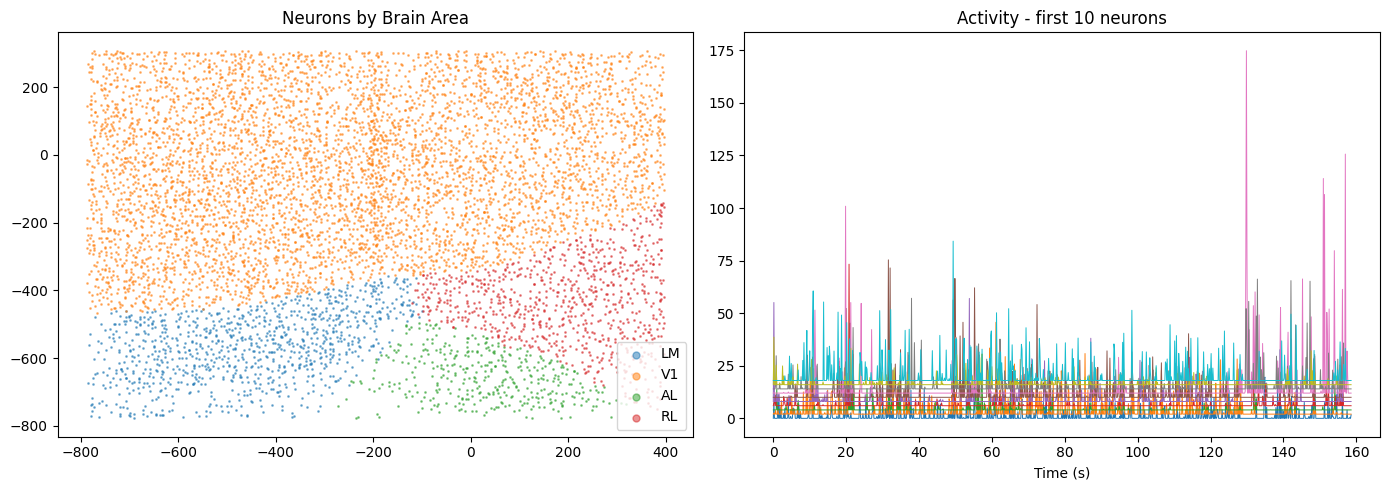

In [17]:
# Load data
data = np.load('/content/microns/activity_s4_scan7.npz')
activity = data['activity']
unit_ids = data['unit_ids']
frame_times = data['frame_times']

meta = pd.read_pickle('/content/microns/metadata.pkl')

# Filter metadata to this scan
meta_s4 = meta[(meta['session'] == 4) & (meta['scan_idx'] == 7)]

# Merge with unit_ids
merged = pd.DataFrame({'unit_id': unit_ids}).merge(meta_s4, on='unit_id')

# Plot 1: Spatial map by brain area
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for area in merged['brain_area'].unique():
    sub = merged[merged['brain_area'] == area]
    axes[0].scatter(sub['um_x'], sub['um_y'], s=1, alpha=0.5, label=area)
axes[0].set_title('Neurons by Brain Area')
axes[0].legend(markerscale=5)

# Plot 2: Activity of first 10 neurons
for i in range(10):
    axes[1].plot(frame_times[:1000], activity[i, :1000] + i * 2, lw=0.7)
axes[1].set_title('Activity - first 10 neurons')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

In [13]:
# Filter metadata to match our scan
meta_s4 = meta[(meta['session'] == 4) & (meta['scan_idx'] == 7)].copy()
print(f"Neurons in this scan: {len(meta_s4)}")
print(f"Brain areas: {meta_s4['brain_area'].value_counts()}")
print(f"Cell types: {meta_s4['cell_type'].value_counts()}")

Neurons in this scan: 7496
Brain areas: brain_area
V1    5315
LM     983
RL     811
AL     387
Name: count, dtype: int64
Cell types: cell_type
23P          630
4P           417
5P-ET        110
5P-IT         83
MC            14
5P-NP          6
astrocyte      2
NGC            1
BPC            1
OPC            1
6P-CT          1
Name: count, dtype: Int64


In [14]:
print(data.files)
for k in data.files:
    print(k, data[k].shape, data[k].dtype)
    print(data[k][:5])

['activity', 'unit_ids', 'frame_times']
activity (7493, 40000) float32
[[3.11461470e-08 7.37604380e+00 5.48100695e-02 ... 1.03101820e-06
  7.10315931e-07 3.98992256e-07]
 [2.47172949e-08 5.92512012e-01 1.38521386e-07 ... 2.93800255e-08
  3.15669801e-08 3.08407060e-08]
 [5.51655432e-09 1.93178593e-08 1.74771237e-08 ... 1.44063899e-08
  1.34048115e-08 1.56373297e-08]
 [9.72854330e-09 1.36003172e+00 3.91264653e+00 ... 1.51964663e-08
  1.18356187e-08 1.14354508e-08]
 [1.29249509e-08 4.70802231e+01 3.36962813e-08 ... 1.67662950e-08
  1.43566066e-08 1.21978010e-08]]
unit_ids (7493,) int64
[1 3 4 5 6]
frame_times (40000,) float64
[0.         0.1587225  0.31741979 0.4760912  0.63469017]


In [66]:
"""
Paths in Dandi
sub-17797/sub-17797_ses-4-scan-7_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-4-scan-9_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-4-scan-10_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-5-scan-3_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-5-scan-6_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-5-scan-7_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-6-scan-2_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-6-scan-4_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-6-scan-6_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-7-scan-4_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-7-scan-5_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-7-scan-3_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-8-scan-5_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-8-scan-7_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-9-scan-3_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-8-scan-9_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-9-scan-4_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-9-scan-6_behavior+image+ophys.nwb
sub-17797/sub-17797_ses-6-scan-7_behavior+image+ophys.nwb
"""

ACTIVITY_PATH = "/content/microns/activity_s4_scan7.npz"
METADATA_PATH = "/content/microns/metadata.pkl"
NWB_PATH = "sub-17797/sub-17797_ses-4-scan-7_behavior+image+ophys.nwb"
SESSION = 4
SCAN = 7

In [69]:
def connect_to_data(nwb_path):
  client = DandiAPIClient()
  dandiset = client.get_dandiset("000402", "draft")
  asset = next(a for a in dandiset.get_assets() if a.path == nwb_path)
  s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)
  rf = remfile.File(s3_url)
  h5 = h5py.File(rf, "r")
  io = NWBHDF5IO(file=h5)
  return io.read()

In [72]:
nwb = connect_to_data(NWB_PATH)
# load activity
# We load the preprocessed activity file which contains three arrays:
# - activity: (n_neurons x n_frames) matrix of neural firing rates
# - unit_ids: the unique ID for each neuron, used to link to metadata
# - frame_times: the timestamp in seconds for each frame of the recording
data = np.load(ACTIVITY_PATH)
activity = data['activity']
unit_ids = data['unit_ids']
frame_times = data['frame_times']

# load metadata
# The metadata is a pandas DataFrame with 25 columns describing each neuron
# across all sessions. We filter it down to just our session and scan.
# We drop duplicate unit_ids (some neurons had multiple cell type classifications)
# and merge with our unit_ids to get one metadata row per neuron in the same
# order as our activity matrix.
meta    = pd.read_pickle(METADATA_PATH)
meta_s4 = meta[(meta['session'] == SESSION) & (meta['scan_idx'] == SCAN)]
meta_s4 = meta_s4.drop_duplicates(subset='unit_id', keep='first')
merged  = pd.DataFrame({'unit_id': unit_ids}).merge(meta_s4, on='unit_id', how='left')
# The um_z column contains the imaging depth in micrometers. In this dataset
# the depths are already discrete imaging planes (80, 220, 360, 500 um) so we
# just convert to integer to use as clean labels for grouping neurons by depth.
merged['depth_bin'] = merged['um_z'].astype(int)

# get trials
# The NWB file contains a trials table called 'Clip' with the start time,
# stop time, and movie name for each stimulus presentation. We filter to only
# the three movie categories we want to decode: sports1m, Cinematic, Rendered.
trials = nwb.intervals['Clip'].to_dataframe()
trials = trials[trials['short_movie_name'].isin(['sports1m', 'Cinematic', 'Rendered'])]
print(f"Trials: {trials['short_movie_name'].value_counts().to_dict()}")

# epoch activity into trials
# We convert the continuous activity trace into a trial x neuron matrix (X).
# For each trial we find all frames whose timestamps fall within the trial's
# start and stop time, then average the activity across those frames.
# This gives us one vector of mean firing rates per trial per neuron.
# The result is X of shape (n_trials, n_neurons) and y of shape (n_trials,)
# where y contains the movie label for each trial.
# This is the input matrix for our decoder - each row is one trial,
# each column is one neuron, and the value is the mean firing rate
# of that neuron during that trial.
X, y = [], []
for _, trial in trials.iterrows():
    mask = (frame_times >= trial.start_time) & (frame_times < trial.stop_time)
    X.append(activity[:, mask].mean(axis=1))
    y.append(trial.short_movie_name)

X = np.array(X)   # (n_trials, n_neurons)
y = np.array(y)

print(f"X: {X.shape}, y: {y.shape}")
print(f"Areas: {merged['brain_area'].value_counts().to_dict()}")
print(f"Depths: {merged['depth_bin'].value_counts().sort_index().to_dict()}")

Trials: {'sports1m': 128, 'Cinematic': 128, 'Rendered': 128}
X: (384, 7493), y: (384,)
Areas: {'V1': 5312, 'LM': 983, 'RL': 811, 'AL': 387}
Depths: {80: 890, 220: 2565, 360: 2528, 500: 1510}


In [74]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X, y_enc, cv=5)
print(f"Accuracy: {scores.mean():.3f} +/- {scores.std():.3f}")
print(f"Chance: {1/3:.3f}")

Accuracy: 0.419 +/- 0.067
Chance: 0.333


In [94]:
def decode(X_subset, y, n_bootstrap=20, n_neurons=200):
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    classes = le.classes_
    n_classes = len(classes)

    accs, accs_shuf = [], []
    cms, cms_shuf = [], []

    for _ in range(n_bootstrap):
        n = min(n_neurons, X_subset.shape[1])
        idx = np.random.choice(X_subset.shape[1], n, replace=False)
        X_boot = X_subset[:, idx]

        cm_boot = np.zeros((n_classes, n_classes))
        cm_boot_shuf = np.zeros((n_classes, n_classes))
        acc_boot, acc_boot_shuf = [], []

        cv = StratifiedKFold(n_splits=5, shuffle=True)
        y_shuf = y_enc.copy()
        np.random.shuffle(y_shuf)

        clf = Pipeline([
            ('scaler', StandardScaler()),
            ('lr', LogisticRegression(max_iter=1000, C=0.01, solver='saga', multi_class='multinomial'))
        ])

        for train, test in cv.split(X_boot, y_enc):
            # real
            clf.fit(X_boot[train], y_enc[train])
            pred = clf.predict(X_boot[test])
            cm_boot += confusion_matrix(y_enc[test], pred, labels=range(n_classes))
            acc_boot.append((pred == y_enc[test]).mean())

            # shuffle
            clf.fit(X_boot[train], y_shuf[train])
            pred_shuf = clf.predict(X_boot[test])
            cm_boot_shuf += confusion_matrix(y_enc[test], pred_shuf, labels=range(n_classes))
            acc_boot_shuf.append((pred_shuf == y_enc[test]).mean())

        cms.append(cm_boot / cm_boot.sum(axis=1, keepdims=True))
        cms_shuf.append(cm_boot_shuf / cm_boot_shuf.sum(axis=1, keepdims=True))
        accs.append(np.mean(acc_boot))
        accs_shuf.append(np.mean(acc_boot_shuf))

    return {
        'acc': np.mean(accs),
        'acc_std': np.std(accs),
        'acc_shuf': np.mean(accs_shuf),
        'acc_shuf_std': np.std(accs_shuf),
        'cm': np.mean(cms, axis=0),
        'cm_shuf': np.mean(cms_shuf, axis=0),
        'classes': classes
    }

In [98]:
results_area = {}
results_depth = {}
results_area_depth = {}

print("By area...")
for area in areas:
    idx = merged['brain_area'].values == area
    results_area[area] = decode(X[:, idx], y, n_bootstrap=20, n_neurons=200)
    print(f"  {area}: {results_area[area]['acc']:.3f} +/- {results_area[area]['acc_std']:.3f} (shuffle: {results_area[area]['acc_shuf']:.3f})")

print("By depth...")
for depth in depths:
    idx = merged['depth_bin'].values == depth
    results_depth[depth] = decode(X[:, idx], y, n_bootstrap=20, n_neurons=200)
    print(f"  {depth}um: {results_depth[depth]['acc']:.3f} +/- {results_depth[depth]['acc_std']:.3f} (shuffle: {results_depth[depth]['acc_shuf']:.3f})")

print("By area x depth...")
for area in areas:
    for depth in depths:
        idx = (merged['brain_area'].values == area) & (merged['depth_bin'].values == depth)
        if idx.sum() >= 50:
            results_area_depth[(area, depth)] = decode(X[:, idx], y, n_bootstrap=20, n_neurons=50)
            print(f"  {area} {depth}um: {results_area_depth[(area, depth)]['acc']:.3f} +/- {results_area_depth[(area, depth)]['acc_std']:.3f} (n={idx.sum()})")
        else:
            print(f"  {area} {depth}um: skipped (n={idx.sum()})")

By area...
  V1: 0.397 +/- 0.027 (shuffle: 0.344)
  LM: 0.418 +/- 0.023 (shuffle: 0.342)
  RL: 0.383 +/- 0.020 (shuffle: 0.332)
  AL: 0.391 +/- 0.023 (shuffle: 0.332)
By depth...
  80um: 0.389 +/- 0.019 (shuffle: 0.336)
  220um: 0.409 +/- 0.020 (shuffle: 0.340)
  360um: 0.404 +/- 0.031 (shuffle: 0.330)
  500um: 0.415 +/- 0.032 (shuffle: 0.331)
By area x depth...
  V1 80um: 0.382 +/- 0.026 (n=832)
  V1 220um: 0.378 +/- 0.033 (n=1714)
  V1 360um: 0.368 +/- 0.025 (n=1710)
  V1 500um: 0.376 +/- 0.031 (n=1056)
  LM 80um: skipped (n=32)
  LM 220um: 0.382 +/- 0.027 (n=385)
  LM 360um: 0.414 +/- 0.029 (n=355)
  LM 500um: 0.374 +/- 0.028 (n=211)
  RL 80um: skipped (n=23)
  RL 220um: 0.354 +/- 0.023 (n=319)
  RL 360um: 0.369 +/- 0.029 (n=310)
  RL 500um: 0.364 +/- 0.026 (n=159)
  AL 80um: skipped (n=3)
  AL 220um: 0.376 +/- 0.016 (n=147)
  AL 360um: 0.368 +/- 0.025 (n=153)
  AL 500um: 0.371 +/- 0.019 (n=84)


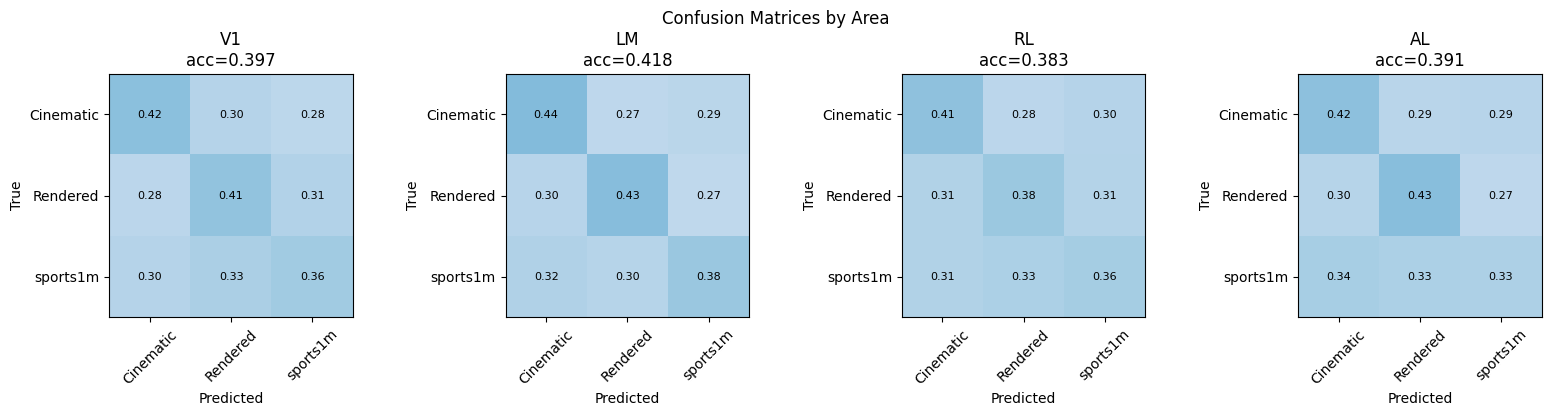

In [99]:
fig, axes = plt.subplots(1, len(areas), figsize=(16, 4))
for ax, area in zip(axes, areas):
    cm = results_area[area]['cm']
    classes = results_area[area]['classes']
    im = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_title(f'{area}\nacc={results_area[area]["acc"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.suptitle('Confusion Matrices by Area')
plt.tight_layout()
plt.show()

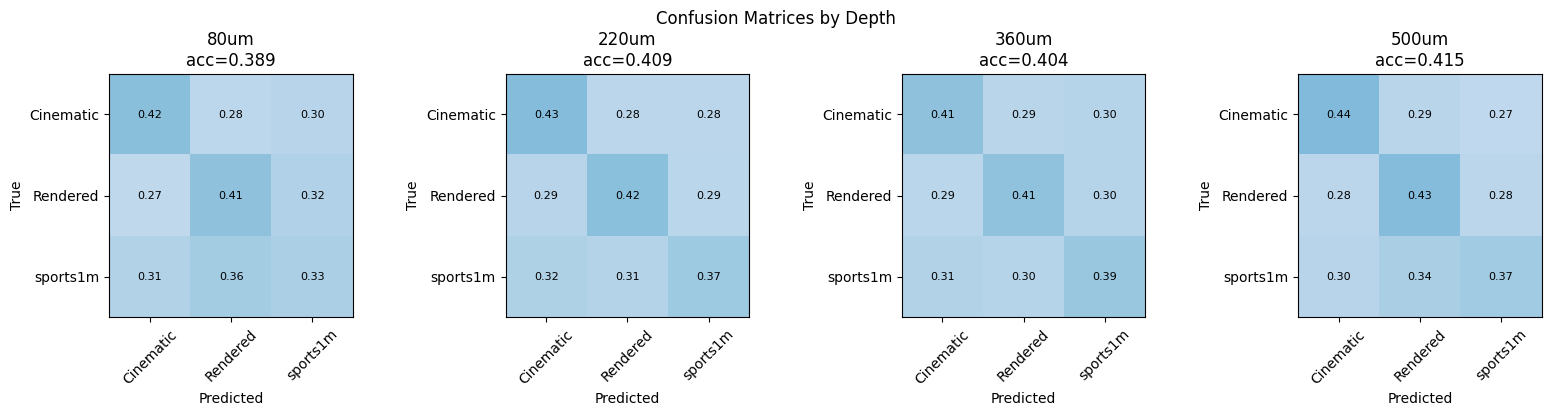

In [100]:
fig, axes = plt.subplots(1, len(depths), figsize=(16, 4))
for ax, depth in zip(axes, depths):
    cm = results_depth[depth]['cm']
    classes = results_depth[depth]['classes']
    im = ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
    ax.set_title(f'{depth}um\nacc={results_depth[depth]["acc"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.suptitle('Confusion Matrices by Depth')
plt.tight_layout()
plt.show()

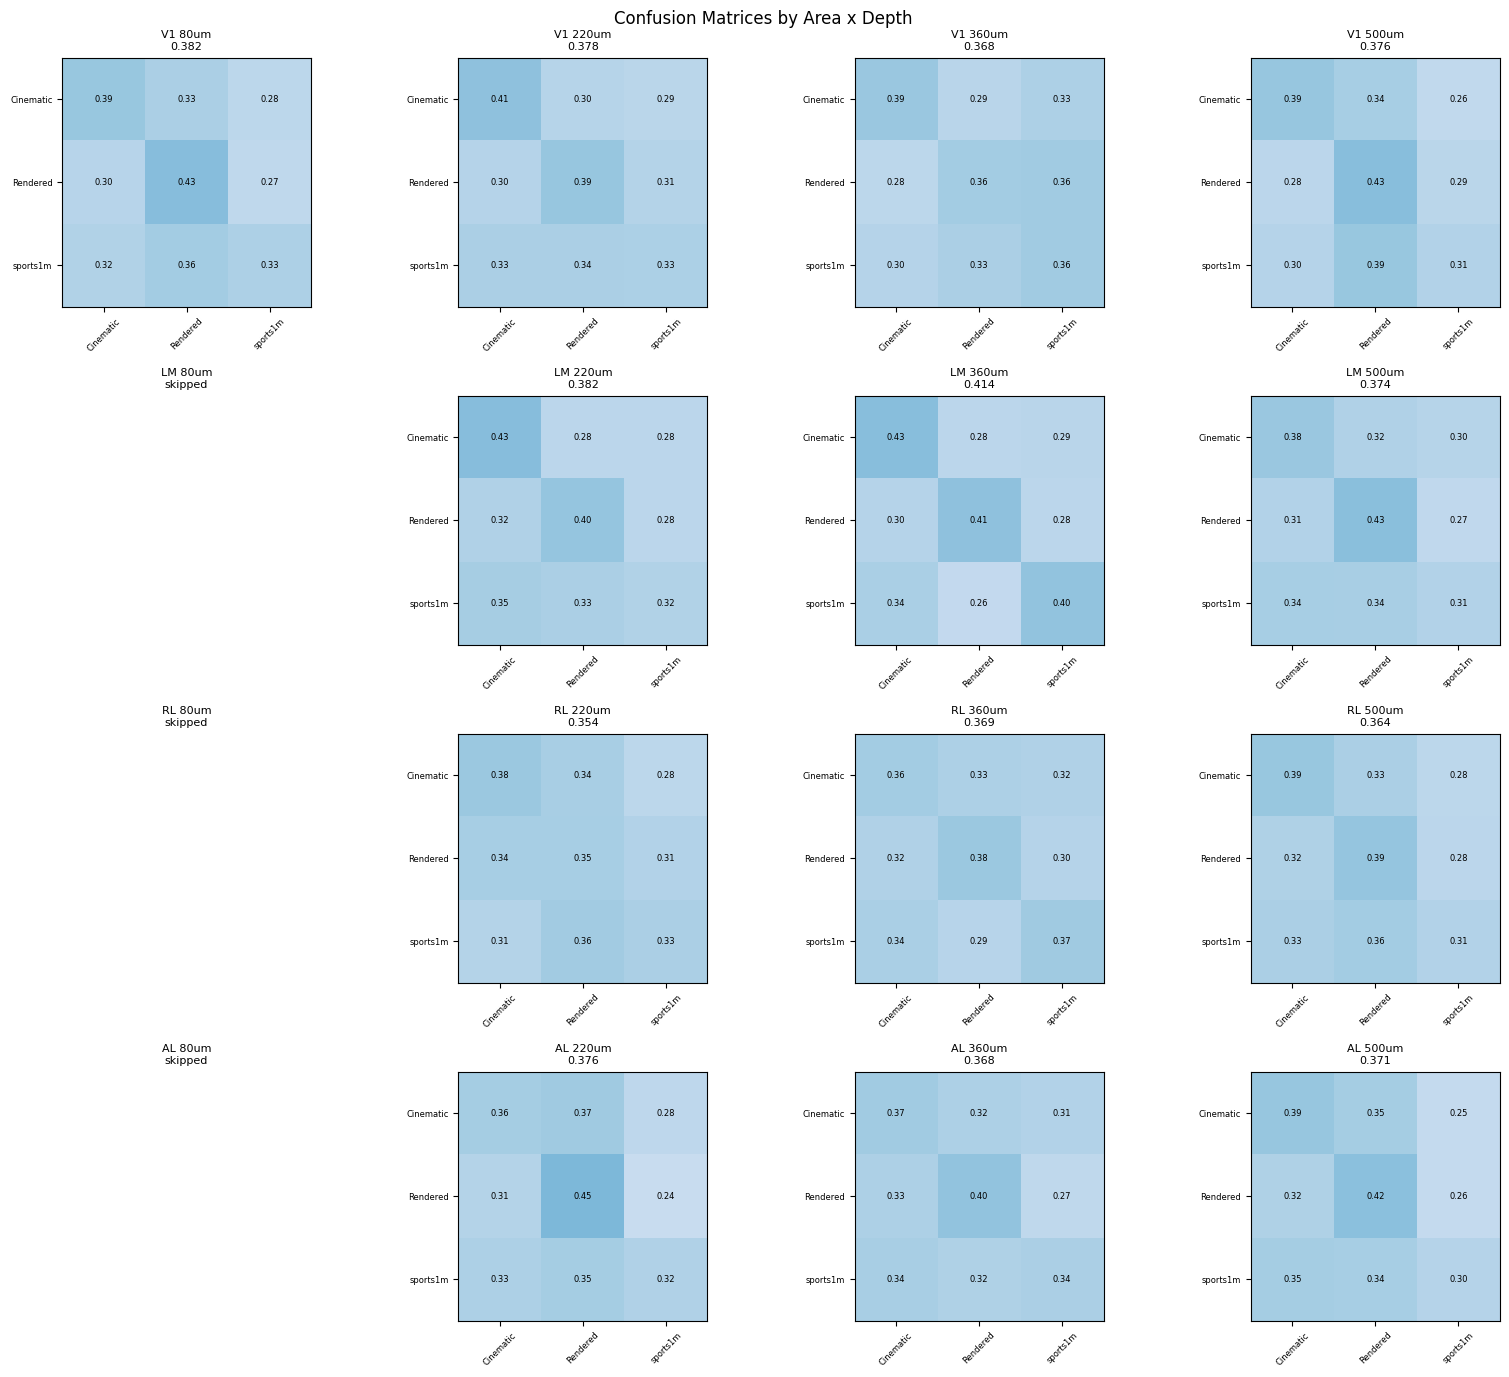

In [101]:
valid_keys = list(results_area_depth.keys())
n_cols = len(depths)
n_rows = len(areas)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
for i, area in enumerate(areas):
    for j, depth in enumerate(depths):
        ax = axes[i, j]
        if (area, depth) in results_area_depth:
            cm = results_area_depth[(area, depth)]['cm']
            classes = results_area_depth[(area, depth)]['classes']
            ax.imshow(cm, vmin=0, vmax=1, cmap='Blues')
            ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, fontsize=6)
            ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=6)
            ax.set_title(f'{area} {depth}um\n{results_area_depth[(area,depth)]["acc"]:.3f}', fontsize=8)
            for r in range(len(classes)):
                for c in range(len(classes)):
                    ax.text(c, r, f'{cm[r,c]:.2f}', ha='center', va='center', fontsize=6)
        else:
            ax.axis('off')
            ax.set_title(f'{area} {depth}um\nskipped', fontsize=8)
plt.suptitle('Confusion Matrices by Area x Depth')
plt.tight_layout()
plt.show()

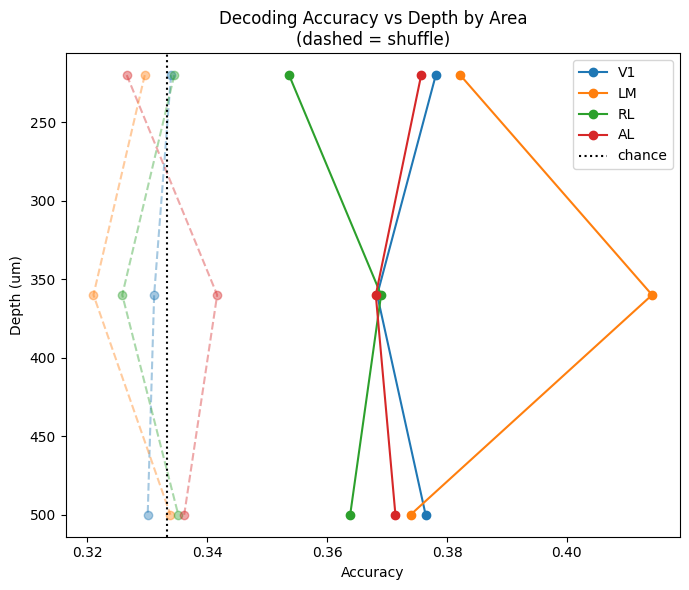

In [105]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = plt.cm.tab10.colors
depth_list = [220, 360, 500]  # skip depths with too many skipped areas

for i, area in enumerate(areas):
    accs, accs_shuf, d_plot = [], [], []
    for depth in depth_list:
        if (area, depth) in results_area_depth:
            accs.append(results_area_depth[(area, depth)]['acc'])
            accs_shuf.append(results_area_depth[(area, depth)]['acc_shuf'])
            d_plot.append(depth)
    ax.plot(accs, d_plot, color=colors[i], marker='o', label=area)
    ax.plot(accs_shuf, d_plot, color=colors[i], marker='o', linestyle='--', alpha=0.4)

ax.axvline(1/3, color='black', linestyle=':', label='chance')
ax.set_xlabel('Accuracy')
ax.set_ylabel('Depth (um)')
ax.set_title('Decoding Accuracy vs Depth by Area\n(dashed = shuffle)')
ax.invert_yaxis()  # shallow at top, deep at bottom
ax.legend()
plt.tight_layout()
plt.show()